# Code for plots in Fig. S4

In [53]:
import numpy as np
import matplotlib as mpl
mpl.use("Qt5Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os,sys,inspect
from scipy.stats import ttest_ind,anderson,mannwhitneyu,entropy

# import modules
from pseudopopulation_intime import Single_var,Behavior
from pseudopopulation_geometry import By_window
currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
parentdir = os.path.dirname(currentdir)
sys.path.insert(0,parentdir)

from utilities import format_violinplot,statistical_annotation,compute_pvalues_trace,\
null_two_conditions,pvalue_bootstrap_corrected,plot_pvalues_trace,format_axs

## Fig  S5A
### Decoding for choice using neural activity (neural decoders) vs behavioral footage (behavioral decoders)

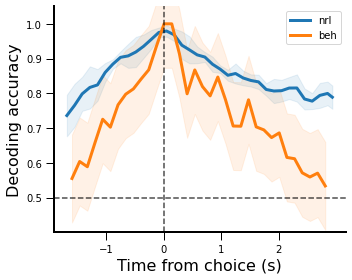

test t-test ind sample
DISC  nrl vs beh pvalue:  5.478915211776437e-161
GT_1  nrl vs beh pvalue:  6.7723253114276e-182
CAT  nrl vs beh pvalue:  2.414709031655619e-170
GT_2  nrl vs beh pvalue:  7.70841739786756e-172


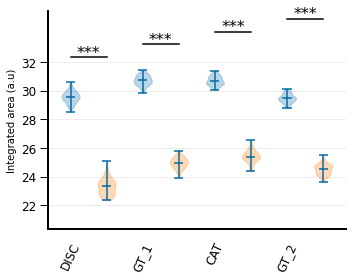

In [31]:
def nrl_vs_beh_trace():
    '''
    plot with neural decoder trace for choice 
    and compared to behavioral 
    decoder trace
    '''
    event_align = 'choice'
    stages = ['discrimination','gentest_1','categorization_4','gentest_2']

    fig,axs = plt.subplots()
    fig.set_figwidth(5)
    fig.set_figheight(4)
    
    acc_av = []
    beh_acc_av = []
    
    for stage in stages:
        entry = Single_var()\
            & 'experimental_timepoint="%s"'%stage & 'variable="choice"' \
                & 'event_align="%s"'%event_align
                
        beh_entry = Behavior()\
            & 'experimental_timepoint="%s"'%stage & 'variable="choice"' \
                & 'event_align="%s"'%event_align

        acc_av.append(np.mean(entry.fetch('accuracies')[0],0))
        beh_acc_av.append(np.mean(beh_entry.fetch('beh_accuracies')[0],0))
        
    acc = np.mean(acc_av,0)
    std_acc = np.std(acc_av,0)
    beh_acc = np.mean(beh_acc_av,0)
    std_beh = np.std(beh_acc,0)
    
    timepoints = entry.fetch('timepoints')[0]
    beh_timepoints = beh_entry.fetch('beh_timepoints')[0]

    # neural decoder
    axs.plot(timepoints,acc,color='tab:blue',linewidth=3,label='nrl')
    axs.fill_between(timepoints, acc-std_acc,\
                                      acc+std_acc, color='tab:blue', alpha=0.1)
    # behavioral decoder
    axs.plot(beh_timepoints,beh_acc,color='tab:orange',linewidth=3,label='beh')
    axs.fill_between(beh_timepoints, beh_acc-std_beh,\
                                      beh_acc+std_beh, color='tab:orange', alpha=0.1)

    axs.axvline(x=0,linestyle='--',color='black',alpha=0.7)
    axs.axhline(y=0.5,linestyle='--',color='black',alpha=0.7)
    axs.set_ylim(0.4,1.05)
    axs.set_yticks(np.arange(0.5,1.05,0.1))
    axs.set_xticks(np.arange(int(timepoints[0]),int(timepoints[-1])+0.5,1))
    axs.spines["top"].set_visible(False)
    axs.spines["right"].set_visible(False)
    axs.spines["bottom"].set_linewidth(2)
    axs.spines["left"].set_linewidth(2)
    axs.legend()
    axs.tick_params(size= 8,width=1, length=10) 
                        
    axs.set_xlabel('Time from %s (s)'%event_align,fontsize=16)
    axs.set_ylabel('Decoding accuracy',fontsize=16)
    plt.tight_layout()
    
    plt.show()
        
def nrl_vs_beh_int():
    
    '''
    plot with neural decoder integrated accuracy over trial time for choice 
    for different stages and compared to behavioral 
    decoder aggregating across subjects
    '''
    event_align = 'choice'
    stages = ['discrimination','gentest_1','categorization_4','gentest_2']

    nr_crossval = 100
    nr_cols = 2 * len(stages)
    data_auc = []
    
    for j,stage in enumerate(stages):
        entry = Single_var()\
            & 'experimental_timepoint="%s"'%stage & 'variable="choice"' \
                & 'event_align="%s"'%event_align
                
        beh_entry = Behavior()\
            & 'experimental_timepoint="%s"'%stage & 'variable="choice"'\
                & 'event_align="%s"'%event_align

        acc = entry.fetch('accuracies')[0]
        beh_acc = beh_entry.fetch('beh_accuracies')[0]
        
        # compute integrated area for trace
        data_auc.append(np.trapz(acc,axis=1))
        data_auc.append(np.trapz(beh_acc,axis=1))
        
    data = np.array(data_auc).T
    assert data.shape == (nr_crossval,nr_cols)
    
    # box plot and pair comparison
    comparisons = [[0,1],[2,3],[4,5],[6,7]]
    column_labels = ['DISC','','GT_1','','CAT','','GT_2','']
    
    fig, axs = plt.subplots()
    fig.set_figheight(4)
    fig.set_figwidth(5)
    
    # violinplot for each column
    colors = []
    for col_label in column_labels:
        if len(col_label) == 0:
            color = 'tab:orange'
        else:
            color = 'tab:blue'
            
        colors.append(color)
        
    axs =  format_violinplot(axs,data,column_labels,colors=colors,
                              y_label='Integrated area (a.u)')
    
    # check normality of samples and select test
    normality = True
    check = True
    test = 't-test ind sample'
    for j in range(nr_cols):
        try:
            check = normality_test(data[:,j])
        except:
            pass
        
        if not check:
            normality = False
            test = 'Mann Whitney U test'
        
    pvalues = []
    print('test', test)
    
    # compute statistical significance
    for c,comparison in enumerate(comparisons):
        col1,col2 = comparison
        
        datapoints1 = data[:,col1]
        datapoints2 = data[:,col2]
        
        if normality:
            stat,p_value = ttest_ind(datapoints1,datapoints2,alternative='two-sided')
        else:
            stat,p_value = mannwhitneyu(datapoints1,datapoints2,alternative='two-sided')

        print(column_labels[col1],' nrl vs beh pvalue: ',p_value)
        pvalues.append(p_value)
            
    ymax = data.max(); ymin = data.min()
    axs,ymaxlim = statistical_annotation(axs,comparisons,pvalues,ymax,ymin)
        
    vals_axis = list(np.arange(int(ymin),int(ymax)+2,2))
    axs.set_yticks(vals_axis)
        
    axs.set_ylim(ymin - 2,ymaxlim + 0.5)
    axs.spines["top"].set_visible(False)
    axs.spines["right"].set_visible(False)
    axs.spines["bottom"].set_linewidth(2)
    axs.spines["left"].set_linewidth(2)
    axs.tick_params(size= 8,width=1, length=10) 
    
    plt.tight_layout()
    
    plt.show()
        
nrl_vs_beh_trace()
nrl_vs_beh_int()

## Fig S6B
###  Pair-wise stage comparison of decoding traces in trial time for category, choice and outcome variables.

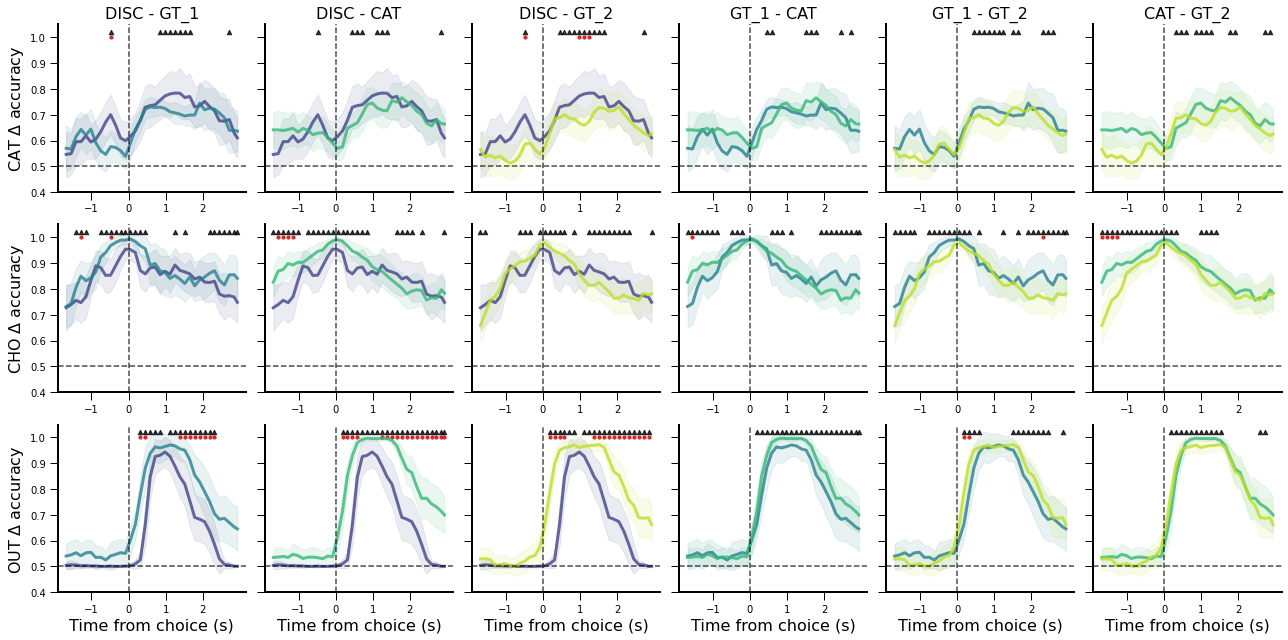

In [32]:
def stage_comparisons():
    variables = ['category','choice','outcome']
    nr_variables = len(variables)
    nr_null_iter = 1000
    column_labels = ['DISC', 'GT_1', 'CAT', 'GT_2']
    threshold = 0.1 # effect size on difference in decoding accuracy when comparing
    event_align = 'choice'
    stages = ['discrimination','gentest_1','categorization_4','gentest_2']
    colors = plt.cm.viridis(np.linspace(0.2,0.9,len(stages)))
    pval_limit = 1.02
    line_limit = 1
    
    # get comparison indices
    comparisons = []
    for j,phase in enumerate(stages):
        for k in range(j,len(stages)):
            if j!=k:
                comparisons.append([j,k])
    
    nr_comparisons = len(comparisons)
    
    # get raw data
    data = []
    pval_bool = []
    for i,v in enumerate(variables):
        d_var = []
        ps_bool = []
        for j,stage in enumerate(stages):
            entry = Single_var()\
                & 'experimental_timepoint="%s"'%stage & 'variable="%s"'%v \
                    & 'event_align="%s"'%event_align
    
            null = entry.fetch('null')[0]
            acc = entry.fetch('accuracies')[0]
            
            pvalues_acc = compute_pvalues_trace(np.mean(acc,0),null,
                                          multiple_correction=True,method='max') 
            ps_bool.append(np.array(pvalues_acc) < 0.05)  
            d_var.append(acc)
            
        pval_bool.append(ps_bool)
        data.append(d_var)
            
    pval_bool = np.array(pval_bool)
    data = np.array(data)
    timepoints = entry.fetch('timepoints')[0]
    nr_timepoints = len(timepoints)
    
    # plot all results
    fig, axs = plt.subplots(nr_variables,nr_comparisons)
    fig.set_figheight(3*nr_variables)
    fig.set_figwidth(3*nr_comparisons)
    
    # get difference for each comparison
    data_comparison = np.zeros((nr_variables,nr_comparisons,nr_timepoints))
    null_comparison = np.zeros((nr_variables,nr_comparisons,nr_null_iter,
                                nr_timepoints))

    for i,v in enumerate(variables):
        for j,comparison in enumerate(comparisons):
            st1, st2 = comparison
            data_comparison[i,j] = np.mean(data[i,st1],0)-np.mean(data[i,st2],0)
            
            m1 = np.mean(data[i,st1],0)
            m2 = np.mean(data[i,st2],0)
            std1 = np.std(data[i,st1],0)
            std2 = np.std(data[i,st2],0)
            
            axs[i,j].plot(timepoints,m1,
                          color=colors[st1],linewidth=3,alpha=0.8)
    
            axs[i,j].plot(timepoints,m2,
                          color=colors[st2],linewidth=3,alpha=0.8)
            
            axs[i,j].fill_between(timepoints, m1-std1,\
                                   m1+std1, color=colors[st1], alpha=0.1)
                
            axs[i,j].fill_between(timepoints, m2-std2,\
                                   m2+std2, color=colors[st2], alpha=0.1)
            
            
            # build null distribution by shuffle and sampling
            null_dist = null_two_conditions(data[i,st1],data[i,st2])
            for n,null_sample in enumerate(null_dist):
                ns_1,ns_2 = null_sample
                null_comparison[i,j,n] = np.mean(ns_1,0)-np.mean(ns_2,0)

            
            pvalues_delta,pvalues_delta_corr = pvalue_bootstrap_corrected(data_comparison[i,j],
                                                              null_comparison[i,j],
                                                              stat_type='two-sided',
                                                              method='bonferroni')
            
            # only consider significant differences between significant traces (at least one)
            pbool = np.logical_or(pval_bool[i,st1],pval_bool[i,st2])
            
            data_th = abs(data_comparison[i,j])
            data_th[pbool==False] = 0
            timepoints_th = timepoints[data_th>threshold]
            d_th = np.repeat(line_limit,len(timepoints_th))
            # plot significant timepoints with > threshold effect size in red
            axs[i,j].scatter(timepoints_th,d_th,
                          color='tab:red',s=10)
            # plot significant timepoints in black
            axs[i,j] = plot_pvalues_trace(axs[i,j],pvalues_delta_corr,timepoints,
                                    pval_limit,'black',alpha=0.8,pbool=pbool)
            
            
            axs[i,j].axvline(x=0,linestyle='--',color='black',alpha=0.7)
            axs[i,j].axhline(y=0.5,linestyle='--',color='black',alpha=0.7)
            axs[i,j].set_ylim(0.4,1.05)
            axs[i,j].set_xticks(np.arange(int(timepoints[0]),int(timepoints[-1])+0.5,1))
            axs[i,j].spines["top"].set_visible(False)
            axs[i,j].spines["right"].set_visible(False)
            axs[i,j].spines["bottom"].set_linewidth(2)
            axs[i,j].spines["left"].set_linewidth(2)
            axs[i,j].tick_params(size= 8,width=1, length=10) # labelsize = labelsize
            
            if j == 0:
                axs[i,j].set_ylabel('%s $\Delta$ accuracy'%v[:3].upper(),fontsize=16)
            else:
                axs[i,j].set_yticklabels([])
            if i == 0:
                axs[i,j].set_title('%s - %s'%(column_labels[st1],column_labels[st2]),fontsize=16)
    
            elif i == len(variables)-1:
                axs[i,j].set_xlabel('Time from %s (s)'%event_align,fontsize=16)
                
            axs[i,j].spines["top"].set_visible(False)
            axs[i,j].spines["right"].set_visible(False)
            axs[i,j].spines["bottom"].set_linewidth(2)
            axs[i,j].spines["left"].set_linewidth(2)
            axs[i,j].tick_params(size= 8,width=1, length=10)
            
    plt.tight_layout()
    
stage_comparisons()

## Fig S6C
### Decoder weight distributions

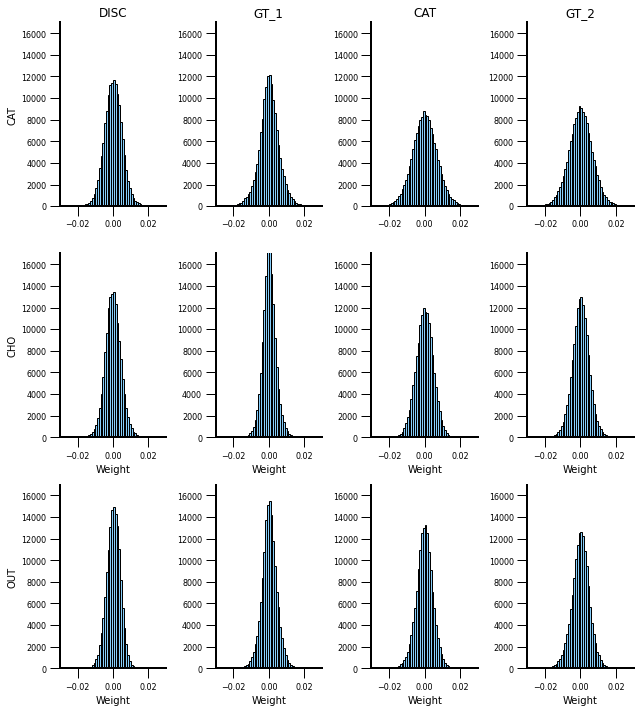

In [49]:
def weight_distributions():
    '''
    all decoder weights in histogram (from window decoding analysis)
    '''
    variables = ['category','choice', 'outcome']
    window = 'post_choice'
    window_length = 1
    stages = ['discrimination','gentest_1','categorization_4','gentest_2']
    stage_labels = ['DISC','GT_1','CAT','GT_2']
    event_align = 'choice'
    bin_edges = np.arange(-0.03,0.03,0.001)
    
    entries_window = By_window() \
                   & 'event_align="%s"'%event_align \
                       & 'window="%s"'%window & 'window_length="%i"'%window_length

    if len(entries_window) != 0:
        mx = []
        mn = []
        for i,variable in enumerate(variables):
            for j, stage in enumerate(stages):

                stage_label = stage_labels[j]
                # weight_distribution
                entry =  By_window() \
                            & 'window="%s"'%window & 'window_length="%i"'%window_length \
                                & 'experimental_timepoint="%s"'%stage \
                                & 'variable="%s"'%variable \
                                    & 'event_align="%s"'%event_align
                if len(entry) != 0:
                    assert len(entry) == 1
                    weight_dist = np.array(entry.fetch('weight_distribution')[0]).flatten()

                    mx.append(np.max(weight_dist))
                    mn.append(np.min(weight_dist))

        fig, axs = plt.subplots(len(variables),len(stages))
        fig.set_figheight(2.5*len(stages))
        fig.set_figwidth(3*len(variables))

        for i,variable in enumerate(variables):
            for j, stage in enumerate(stages):
                stage_label = stage_labels[j]
                # weight_distribution
                entry =  By_window() \
                            & 'window="%s"'%window & 'window_length="%i"'%window_length \
                                & 'experimental_timepoint="%s"'%stage \
                                & 'variable="%s"'%variable \
                                    & 'event_align="%s"'%event_align 

                if len(entry) != 0:
                    weight_dist = np.array(entry.fetch('weight_distribution')[0]).flatten()
                    #histogram
                    res = anderson(weight_dist, 'norm')

                    axs[i,j].hist(weight_dist, bins=bin_edges, edgecolor='black', color='#87CEFA')

                    # Customize the plot
                    axs[i,j].set_xlim(-0.03,0.03)
                    axs[i,j].set_ylim(0,17000)

                    if j == 0:
                        axs[i,j].set_ylabel('%s'%variable[:3].upper())
                    if i == 0:
                        axs[i,j].set_title('%s'%stage_label)
                    else:
                        axs[i,j].set_xlabel('Weight')

                    axs[i,j] = format_axs(axs[i,j])   
                else:
                    axs[i,j].set_axis_off()

        plt.tight_layout()
        plt.show()

weight_distributions()

## Fig S6D & S6E
### Decoder weight entropy distribution across stages and example cell weight profiles

window:  post_stimulus


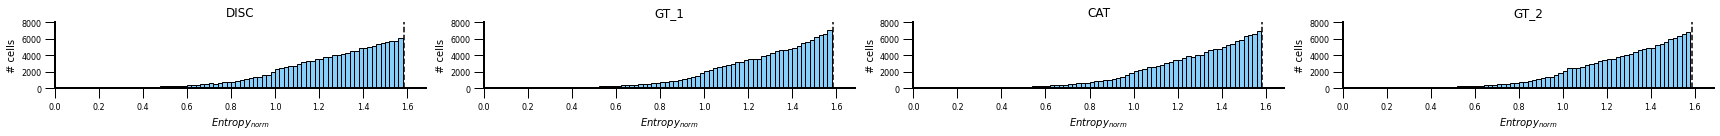

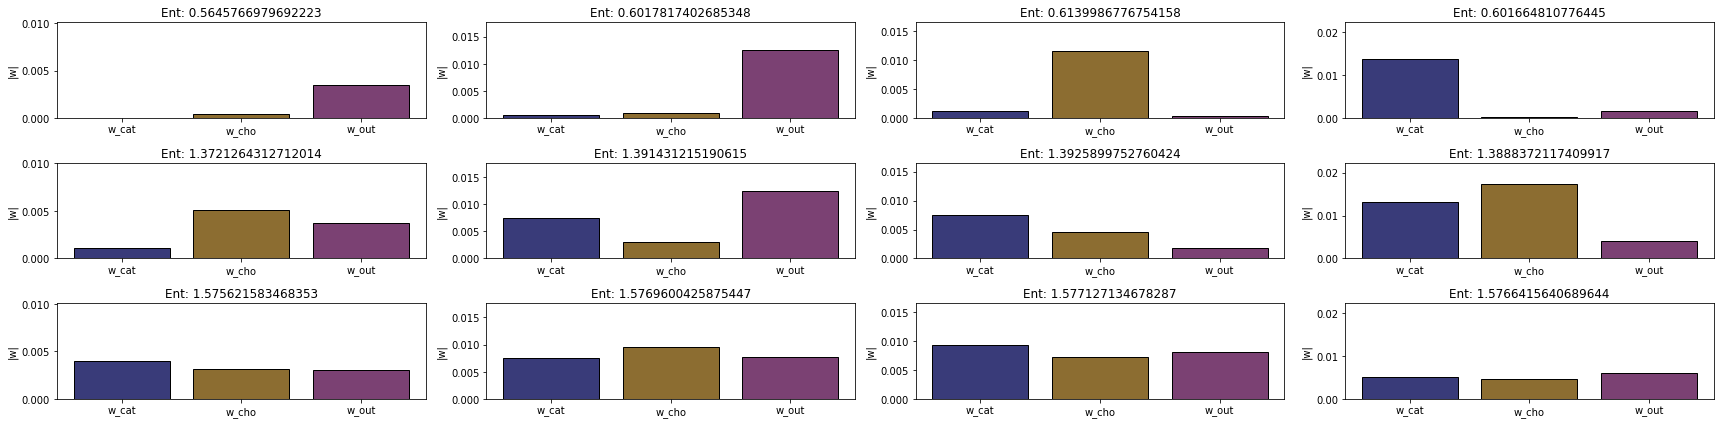

window:  post_choice


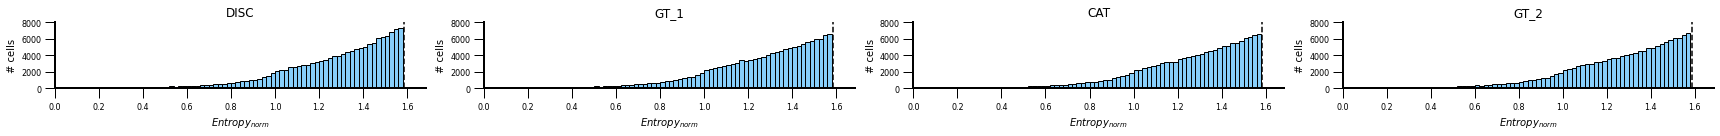

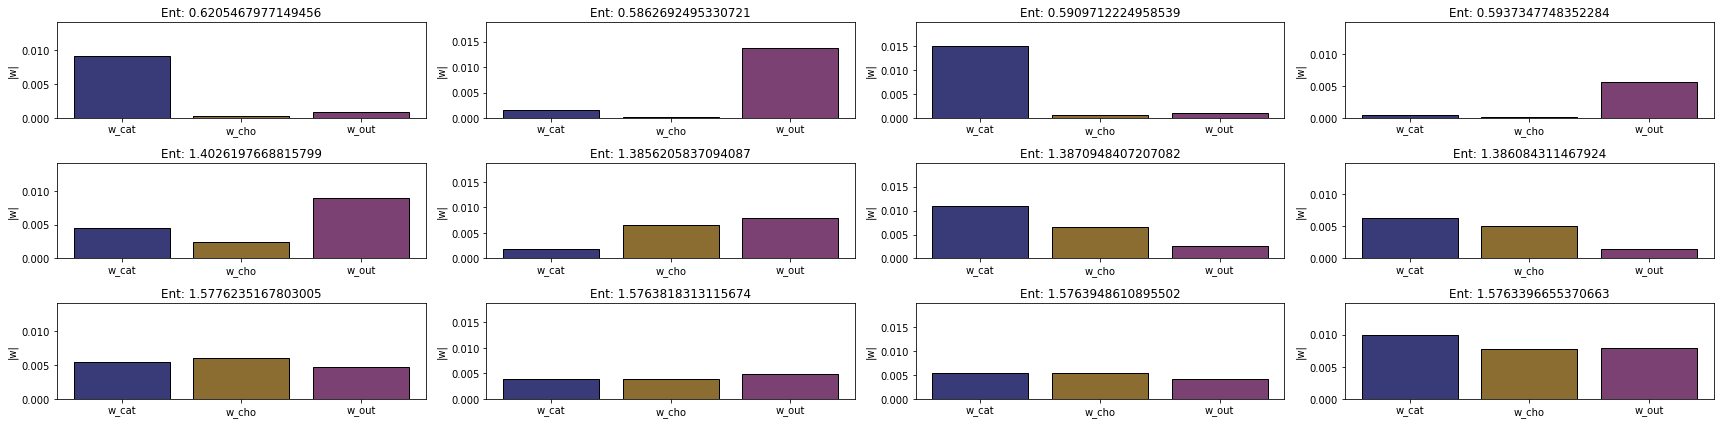

window:  post_outcome


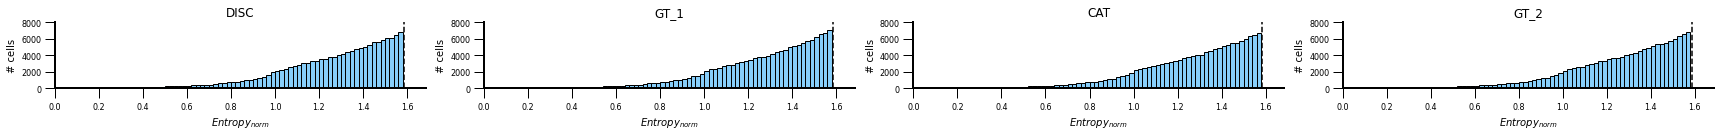

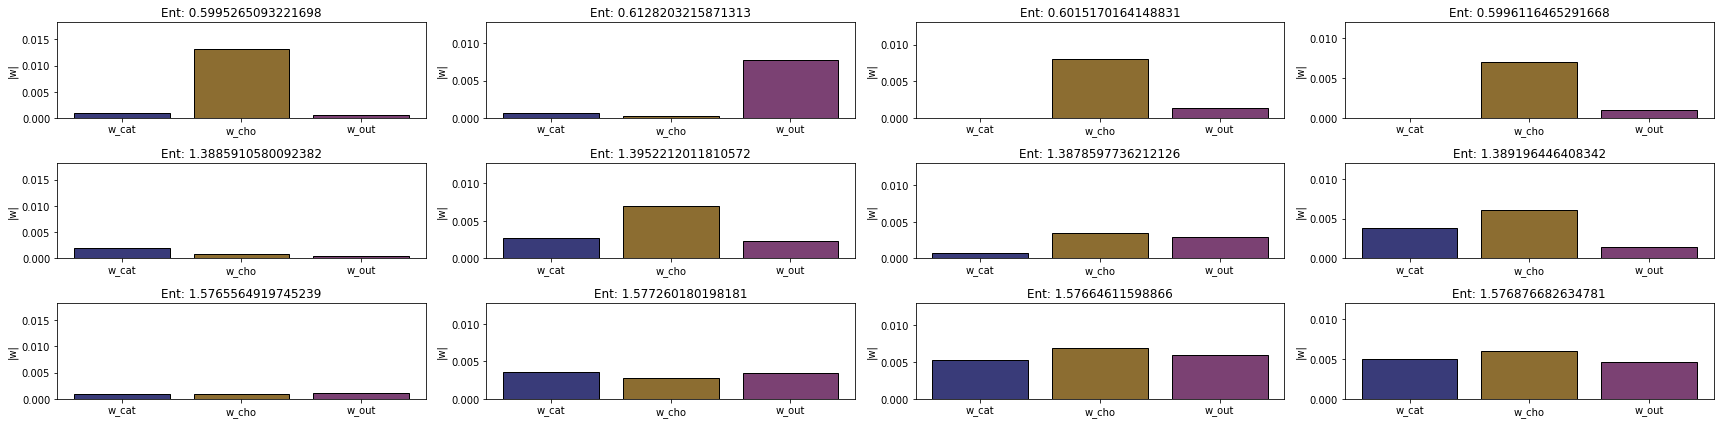

In [58]:
def cell_entropies():
    variables = ['category','choice', 'outcome']
    windows = ['post_stimulus','post_choice','post_outcome']
    window_length = 1
    stages = ['discrimination','gentest_1','categorization_4','gentest_2']
    stage_labels = ['DISC','GT_1','CAT','GT_2']
    event_alignments = ['stimulus_on','choice','ports_off']
    max_entropy = np.log2(3)
    bin_edges = np.arange(0,max_entropy,0.02)
    per_vals = [0.02,0.6,0.98]
    weights = ['w_cat','w_cho','w_out']
    bar_colors = plt.cm.tab20b(np.linspace(0,0.8,len(variables)))

    for n,window in enumerate(windows):
        print('window: ',window)
        event_align = event_alignments[n]
        
        entries_window = By_window() \
                       & 'event_align="%s"'%event_align \
                           & 'window="%s"'%window & 'window_length="%i"'%window_length

        if len(entries_window) != 0:
            fig, axs = plt.subplots(1,len(stages))
            fig.set_figheight(2)
            fig.set_figwidth(8*len(variables))

            w_vals = np.zeros((len(stages),len(per_vals),len(variables)))
            cell_entropies = np.zeros((len(stages),len(per_vals)))
            for i, stage in enumerate(stages):
                stage_label = stage_labels[i]
                all_weights = []
                for j,variable in enumerate(variables):
                    # weight_distribution
                    entry =  By_window() \
                                & 'window="%s"'%window & 'window_length="%i"'%window_length \
                                    & 'experimental_timepoint="%s"'%stage \
                                    & 'variable="%s"'%variable \
                                        & 'event_align="%s"'%event_align

                    if len(entry) != 0:
                        weight_dist = np.array(entry.fetch('weight_distribution')[0]).flatten()
                        all_weights.append(abs(weight_dist))


                all_weights = np.array(all_weights)
                entropies = entropy(all_weights,axis=0,base=2)

                sorted_ent = np.argsort(entropies)

                for pe,per in enumerate(per_vals):
                    pe_index = sorted_ent[int(len(sorted_ent) * per)]
                    w_vals[i,pe] = all_weights[:,pe_index]
                    cell_entropies[i,pe] = entropies[pe_index]

                axs[i].hist(entropies, bins=bin_edges, 
                              edgecolor='black', color='#87CEFA')

                # Customize the plot
                axs[i].set_xlim(0,np.log2(3)+0.1)
                axs[i].set_yticks(np.arange(0,10000,2000))
                axs[i].axvline(x=np.log2(3),linestyle='--',color='black')
                axs[i].set_title('%s'%stage_label)
                axs[i].set_xlabel('$Entropy_{norm}$')
                axs[i].set_ylabel('# cells')

                # Add grid lines for better readability
                axs[i] = format_axs(axs[i])   

            plt.tight_layout()
               # plot example cells
            fig_entropy, axse = plt.subplots(len(per_vals),len(stages))
            fig_entropy.set_figheight(2*len(per_vals))
            fig_entropy.set_figwidth(8*len(variables))

            for i, stage in enumerate(stages):
                m_vals = np.max(w_vals[i])
                for pe in range(len(per_vals)):
                    axse[pe,i].bar(weights, w_vals[i,pe],
                                   edgecolor='black', color=bar_colors)
                    axse[pe,i].set_ylim(0,m_vals+0.005)
                    cell_entropy = cell_entropies[i,pe]
                    axse[pe,i].set_title('Ent: %s'%str(cell_entropy))
                    axse[pe,i].set_ylabel('|w|')

            plt.tight_layout()
            plt.show()
        
cell_entropies()